
*******************************************************************
Download dataset from: https://github.com/smartbugs/smartbugs-wild
*******************************************************************



/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loaded 2000 contracts.
[INFO] Indexed 47398 Solidity files.
[INFO] After code join: 92 contracts with source code.
[RUNNING STRICT SLITHER]
[STRICT] Starting compilation-based analysis...
[STRICT] success=81, failed=11 | time=26.37s
[RUNNING EXPANDED SLITHER]
[EXPANDED] Using solc 0.5.17 (ignore compile)
[EXPANDED] total_json_files=0 | time=39.55s
[LOAD_VULNS] Found 414 files for suffix _strict
[LOAD_VULNS] Found 35 files for suffix _expanded
[SAVE] vuln_heatmap_strict_top15.csv (15, 3)

Label distributions:
STRICT:
 strict_label
1    46
0    46
Name: count, dtype: int64
EXPANDED:
 expanded_label
0    88
1     4
Name: count, dtype: int64

[DEBUG] Dataset sizes:
contracts_df: (92, 12)

===== BASELINE MODEL — TF-IDF + Logistic Regression (Optimised) =====

[STRICT] Training TF-IDF optimised baseline...
[STRICT] After SMOTE (train only): (70, 10000)


/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



=== STRICT TF-IDF PERFORMANCE (Optimised) ===
              precision    recall  f1-score   support

           0     0.7500    0.7500    0.7500        12
           1     0.7273    0.7273    0.7273        11

    accuracy                         0.7391        23
   macro avg     0.7386    0.7386    0.7386        23
weighted avg     0.7391    0.7391    0.7391        23

Confusion:
 [[9 3]
 [3 8]]
AUC-ROC: 0.8485
Best Params: {'C': 1, 'class_weight': 'balanced', 'max_iter': 3000, 'solver': 'lbfgs'}
[SAVE] tfidf_strict_predictions.csv (23, 4)

Top predictive TF-IDF tokens:
uint 0.4185
tokens 0.3717
token 0.2978
persons -0.2587
responsehash -0.2518
islocked 0.2451
eachvar -0.231
emit -0.2305
uint tokens 0.2195
constant returns 0.2166


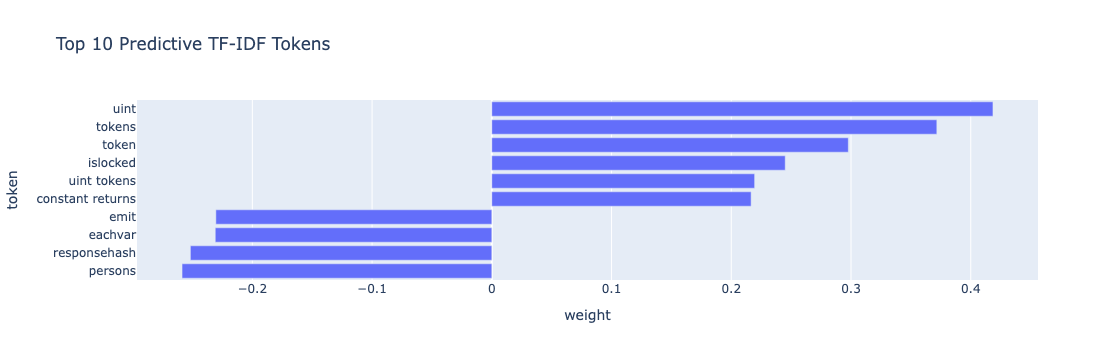

[SAVE] tfidf_predictions.csv written

[EXPANDED] Training TF-IDF baseline...

=== EXPANDED TF-IDF PERFORMANCE (Baseline Only) ===
              precision    recall  f1-score   support

           0     0.9565    1.0000    0.9778        22
           1     0.0000    0.0000    0.0000         1

    accuracy                         0.9565        23
   macro avg     0.4783    0.5000    0.4889        23
weighted avg     0.9149    0.9565    0.9353        23

⚠️ WARNING: Expanded accuracy is misleading because high-risk cases ≪ 10%
Confusion:
 [[22  0]
 [ 1  0]]


/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [1]:
"""
AI-Driven Risk Detection and governance framework for DeFi platforms using Smart Contracts
University of Liverpool MSc Dissertation

Pipeline:
1. Load SmartBugs-Wild dataset
2. Run Slither static analysis
3. Generate vulnerability labels
4. Train TF-IDF logistic regression model
5. Train CodeBERT embedding classifier
6. Optional GraphSAGE experiment
7. Generate contract risk scores
8. Export outputs for Streamlit dashboard
"""

print("")
print("*******************************************************************")
print("Download dataset from: https://github.com/smartbugs/smartbugs-wild")
print("*******************************************************************")
print("")

# ============================================================
# SECTION 1 — IMPORTS 
# ============================================================
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import os, json, time, subprocess
from pathlib import Path
from typing import Dict, Optional, List, Tuple
import re

import pandas as pd
import numpy as np

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_recall_fscore_support
)

from imblearn.over_sampling import SMOTE

# Transformers
from transformers import RobertaTokenizer, RobertaModel
import torch
from transformers.trainer import Trainer

# Try importing GNN libs — optional
try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader as GeoLoader
    from torch_geometric.nn import SAGEConv, global_mean_pool
    import torch.nn.functional as F
    GNN_AVAILABLE = True
except:
    GNN_AVAILABLE = False
    print("[WARN] torch_geometric not available — graph model will be skipped.")


# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

DATA_DIR = Path("/Users/sk/Documents/Liverpool/Dissertation/smartbugs-wild-master")
METADATA_PATH = DATA_DIR / "contracts.csv"
CONTRACTS_DIR = DATA_DIR / "contracts"
LABELS_DIR = DATA_DIR / "labels"; LABELS_DIR.mkdir(exist_ok=True)

SAMPLE_N = 2000   
RANDOM_STATE = 42

SLITHER = "/Users/sk/anaconda3/envs/codebert-env/bin/slither"
SOLC_SELECT = "/opt/homebrew/bin/solc-select"


HIGH_RISK_CHECKS = {
    "reentrancy","delegatecall","tx-origin","unchecked-send","arbitrary-send",
    "suicidal","weak-prng","missing-zero-check","incorrect-equality",
    "uninitialized-storage","dangerous-owner","deprecated-standards",
    "arbitrary-call","reentrancy-no-eth","unchecked-transfer","missing-authorization"
}

model_metrics = {
    "TF-IDF": {},
    "CodeBERT": {},
    "CodeBERT-FT": {},
    "GraphSAGE": {}
}

# ------------------------------------------------------------
# LOAD METADATA
# ------------------------------------------------------------
contracts_df = pd.read_csv(METADATA_PATH)
contracts_df["contract_id"] = contracts_df["address"].astype(str).str.lower()

# deterministic sampling
contracts_df = (
    contracts_df.sample(n=SAMPLE_N, random_state=RANDOM_STATE)
                .sort_values("contract_id")
                .reset_index(drop=True)
)
print(f"[INFO] Loaded {len(contracts_df)} contracts.")


# ------------------------------------------------------------
# SECTION 2 – SLITHER AND LABELING
# ------------------------------------------------------------

# ------------------------------------------------------------
# INDEX SOLIDITY FILES (FAST IO)
# ------------------------------------------------------------

def build_solidity_index(root: Path) -> Dict[str, Path]:
    index = {}
    for sol in root.rglob("*.sol"):
        stem = sol.stem.lower()
        if stem.startswith("0x"):
            index.setdefault(stem, sol)
    return index

file_index = build_solidity_index(CONTRACTS_DIR)
print(f"[INFO] Indexed {len(file_index)} Solidity files.")

# ------------------------------------------------------------
# LOAD SOURCE CODE
# ------------------------------------------------------------

def load_code(addr: str) -> Optional[str]:
    path = file_index.get(addr)
    if not path:
        return None
    return path.read_text(errors="ignore")

contracts_df["code"] = contracts_df["contract_id"].apply(load_code)
contracts_df = contracts_df.dropna(subset=["code"])
print(f"[INFO] After code join: {len(contracts_df)} contracts with source code.")

# =============================================================
# SLITHER EXECUTION PIPELINES
# =============================================================

def run_slither_strict(df: pd.DataFrame, index: dict, labels_dir: Path):
    """
    STRICT mode: only keep contracts that successfully compile
    under at least one solc version.
    """
    start = time.time()
    labels_dir.mkdir(parents=True, exist_ok=True)
    success, failed = 0, 0

    print("[STRICT] Starting compilation-based analysis...")

    for addr in df["contract_id"]:
        sol_path = index.get(addr)
        if not sol_path:
            continue

        out_file = labels_dir / f"{addr}_strict.json"
        if out_file.exists():
            success += 1
            continue

        compilable = False
        for solc in ("0.4.24", "0.5.17", "0.6.12", "0.8.0"):
            subprocess.run(
                [SOLC_SELECT, "use", solc],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
            result = subprocess.run(
                [SLITHER, str(sol_path), "--json", str(out_file)],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
            if result.returncode == 0 and out_file.exists():
                compilable = True
                success += 1
                break

        if not compilable:
            failed += 1

        # STOP EARLY if after 50 files 0 successes → strict impossible
        if failed >= 50 and success == 0:
            elapsed = round(time.time() - start, 2)
            print("[STRICT] ❌ No compilable contracts detected → stopping early.")
            print(f"        This dataset CANNOT be used for strict supervised ML. | time={elapsed}s")
            return

    elapsed = round(time.time() - start, 2)
    print(f"[STRICT] success={success}, failed={failed} | time={elapsed}s")


def run_slither_expanded(df: pd.DataFrame, index: dict, labels_dir: Path):
    """
    EXPANDED mode: use --ignore-compile to maximise number of
    JSON reports, even for syntactically broken contracts.
    """
    start = time.time()
    labels_dir.mkdir(parents=True, exist_ok=True)
    success = 0

    print("[EXPANDED] Using solc 0.5.17 (ignore compile)")
    # switch compiler ONCE (not every loop)
    subprocess.run(
        [SOLC_SELECT, "use", "0.5.17"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

    for addr in df["contract_id"]:
        sol_path = index.get(addr)
        if not sol_path:
            continue

        out_file = labels_dir / f"{addr}_expanded.json"
        if out_file.exists():
            continue

        subprocess.run(
            [SLITHER, str(sol_path), "--json", str(out_file), "--ignore-compile"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        if out_file.exists():
            success += 1

    elapsed = round(time.time() - start, 2)
    print(f"[EXPANDED] total_json_files={success} | time={elapsed}s")

# =============================================================
# LOAD SLITHER FINDINGS
# =============================================================

def load_vulns(suffix: str) -> pd.DataFrame:
    """
    Load Slither JSON outputs and normalise into:
    contract_id, check_name
    """
    rows = []
    json_files = list(LABELS_DIR.glob(f"*{suffix}.json"))
    print(f"[LOAD_VULNS] Found {len(json_files)} files for suffix {suffix}")

    for f in json_files:
        try:
            report = json.loads(f.read_text(errors="ignore"))
        except Exception:
            continue
        detectors = report.get("results", {}).get("detectors", [])
        for d in detectors:
            raw = str(d.get("check", "")).lower()
            check_name = raw.replace("-eth", "").replace("-solc", "").strip()
            if check_name:
                rows.append({
                    "contract_id": f.stem.replace(suffix, "").lower(),
                    "check_name": check_name
                })

    return pd.DataFrame(rows, columns=["contract_id", "check_name"])

# =============================================================
# RUN PIPELINES
# =============================================================

print("[RUNNING STRICT SLITHER]")
run_slither_strict(contracts_df, file_index, LABELS_DIR)

print("[RUNNING EXPANDED SLITHER]")
run_slither_expanded(contracts_df, file_index, LABELS_DIR)

# Load datasets
strict = load_vulns("_strict")
expanded = load_vulns("_expanded")

# Filter to sampled set only
strict = strict[strict["contract_id"].isin(contracts_df["contract_id"])]
expanded = expanded[expanded["contract_id"].isin(contracts_df["contract_id"])]

# Label assignment
contracts_df["strict_label"] = contracts_df["contract_id"].isin(
    strict[strict["check_name"].isin(HIGH_RISK_CHECKS)]["contract_id"]
).astype(int)

contracts_df["expanded_label"] = contracts_df["contract_id"].isin(
    expanded[expanded["check_name"].isin(HIGH_RISK_CHECKS)]["contract_id"]
).astype(int)
 


# =============================================================
# VULNERABILITY HEATMAP (BY CHECK_NAME COUNTS)
# =============================================================
# Merge vulnerabilities with strict labels
strict_v = strict.merge(
    contracts_df[["contract_id", "strict_label"]],
    on="contract_id",
    how="inner"
)

# Count checks by label
heat = (
    strict_v.groupby(["check_name", "strict_label"])
            .size()
            .unstack(fill_value=0)
            .rename(columns={0: "low_risk", 1: "high_risk"})
            .sort_values("high_risk", ascending=False)
)

# Keep top 15 checks for dashboard readability
heat_top = heat.head(15).reset_index()

# Save for Streamlit*****
heat_top.to_csv("/Users/sk/Documents/Liverpool/Dissertation/vuln_heatmap_strict_top15.csv", index=False)
print("[SAVE] vuln_heatmap_strict_top15.csv", heat_top.shape)



print("\nLabel distributions:")
print("STRICT:\n", contracts_df["strict_label"].value_counts())
print("EXPANDED:\n", contracts_df["expanded_label"].value_counts())

# ==============================
# DEBUG — DATA CHECK
# ==============================

print("\n[DEBUG] Dataset sizes:")
print("contracts_df:", contracts_df.shape)

if contracts_df.empty:
    raise ValueError("contracts_df is EMPTY — stop pipeline")

if contracts_df["code"].isna().all():
    raise ValueError("No Solidity code loaded — check path")



# =============================================================
# SECTION 3 – TF-IDF + Logistic Regression (Optimised)
# =============================================================

print("\n===== BASELINE MODEL — TF-IDF + Logistic Regression (Optimised) =====")

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

#  Fit TF-IDF globally once
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,3),
    lowercase=True,
    token_pattern=r"[A-Za-z_][A-Za-z0-9_]*"
)
tfidf.fit(contracts_df["code"])

# =============================================================
# STRICT DATASET 
# =============================================================

strict_df = contracts_df[contracts_df["strict_label"].isin([0, 1])].reset_index(drop=True)

if strict_df["strict_label"].nunique() == 2:
    print("\n[STRICT] Training TF-IDF optimised baseline...")

    Xs = tfidf.transform(strict_df["code"])
    ys = strict_df["strict_label"].values

    # Split FIRST on real contracts
    idx_all = np.arange(len(strict_df))
    idx_train, idx_test = train_test_split(
        idx_all,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=ys
    )

    Xs_train, Xs_test = Xs[idx_train], Xs[idx_test]
    ys_train, ys_test = ys[idx_train], ys[idx_test]

    # Apply SMOTE ONLY to training fold
    sm = SMOTE(random_state=RANDOM_STATE)
    Xs_train_res, ys_train_res = sm.fit_resample(Xs_train, ys_train)
    print("[STRICT] After SMOTE (train only):", Xs_train_res.shape)

    param_grid = {
        "C": [0.1, 1, 2],
        "solver": ["lbfgs"],
        "class_weight": ["balanced"],
        "max_iter": [3000]
    }

    grid = GridSearchCV(
        LogisticRegression(),
        param_grid,
        scoring="f1_macro",
        cv=3,
        verbose=0,
        n_jobs=-1
    )
    grid.fit(Xs_train_res, ys_train_res)
    lr_strict_best = grid.best_estimator_

    preds_tfidf = lr_strict_best.predict(Xs_test)
    probs_tfidf = lr_strict_best.predict_proba(Xs_test)[:, 1]
    auc_tfidf = roc_auc_score(ys_test, probs_tfidf)

    print("\n=== STRICT TF-IDF PERFORMANCE (Optimised) ===")
    print(classification_report(ys_test, preds_tfidf, digits=4))
    print("Confusion:\n", confusion_matrix(ys_test, preds_tfidf))
    print("AUC-ROC:", round(auc_tfidf, 4))
    print("Best Params:", grid.best_params_)

    precision, recall, f1, _ = precision_recall_fscore_support(
        ys_test, preds_tfidf, average="macro"
    )
    acc = accuracy_score(ys_test, preds_tfidf)

    model_metrics["TF-IDF"] = {
        "accuracy": round(acc, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "auc_roc": round(auc_tfidf, 4)
    }

    tfidf_pred_df = strict_df.iloc[idx_test][["contract_id", "strict_label"]].copy()
    tfidf_pred_df = tfidf_pred_df.rename(columns={"strict_label": "true_label"})
    tfidf_pred_df["tfidf_pred_label"] = preds_tfidf
    tfidf_pred_df["tfidf_risk_prob"] = probs_tfidf

else:
    print("\n[STRICT] ⚠️ Cannot train baseline — only one class present!")

from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# strict TF-IDF
precision, recall, f1, _ = precision_recall_fscore_support(ys_test, preds_tfidf, average="macro")
acc = accuracy_score(ys_test, preds_tfidf)

# ✅ AFTER you have: strict_df, ys, ys_test, preds_tfidf (and RANDOM_STATE, test_size=0.25)

# 1) rebuild identical test indices
idx_all = np.arange(len(strict_df))  # positions 0..len(strict_df)-1

_, idx_test = train_test_split(
    idx_all,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=strict_df["strict_label"].values
)


# If you have probabilities available, add them safely:
if "lr_strict_best" in globals():
    try:
        tfidf_pred_df["tfidf_risk_prob"] = lr_strict_best.predict_proba(Xs_test)[:, 1]
    except Exception:
        tfidf_pred_df["tfidf_risk_prob"] = np.nan

tfidf_pred_df.to_csv("tfidf_strict_predictions.csv", index=False)
print("[SAVE] tfidf_strict_predictions.csv", tfidf_pred_df.shape)


# ==============================
# FEATURE IMPORTANCE
# ==============================

feature_names = tfidf.get_feature_names_out()
coef = lr_strict_best.coef_[0]

# Pair each token with its coefficient
feature_weights = list(zip(feature_names, coef))

# Sort by absolute importance
top_features = sorted(
    feature_weights,
    key=lambda x: abs(x[1]),
    reverse=True
)

# Optional: filter out very short / noisy tokens
top_features = [
    (tok, w) for tok, w in top_features
    if len(tok) > 3 and "_" not in tok
][:10]

print("\nTop predictive TF-IDF tokens:")
for token, weight in top_features:
    print(token, round(weight, 4))

# Plot
import plotly.express as px

top10_df = pd.DataFrame(top_features, columns=["token", "weight"])
fig_top_tokens = px.bar(
    top10_df.sort_values("weight"),
    x="weight",
    y="token",
    orientation="h",
    title="Top 10 Predictive TF-IDF Tokens"
)
fig_top_tokens.show()




# ==============================
# SAVE TF-IDF OUTPUT
# ==============================

tfidf_results = pd.DataFrame({
    "model": "TF-IDF",
    "true_label": ys_test,
    "predicted_label": preds_tfidf
})

tfidf_results.to_csv("tfidf_predictions.csv", index=False)

print("[SAVE] tfidf_predictions.csv written")



# =============================================================
# EXPANDED DATASET
# =============================================================
expanded_df = contracts_df[contracts_df["expanded_label"].isin([0,1])]

if expanded_df["expanded_label"].nunique() == 2:
    print("\n[EXPANDED] Training TF-IDF baseline...")

    Xe = tfidf.transform(expanded_df["code"])
    ye = expanded_df["expanded_label"].values

    # ❗ DO NOT apply SMOTE on expanded – artificially inflated positives
    Xe_train, Xe_test, ye_train, ye_test = train_test_split(
        Xe, ye, test_size=0.25, random_state=RANDOM_STATE, stratify=ye
    )

    lr_expanded = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs"
    ).fit(Xe_train, ye_train)

    preds_e = lr_expanded.predict(Xe_test)

    print("\n=== EXPANDED TF-IDF PERFORMANCE (Baseline Only) ===")
    print(classification_report(ye_test, preds_e, digits=4))
    print("⚠️ WARNING: Expanded accuracy is misleading because high-risk cases ≪ 10%")
    print("Confusion:\n", confusion_matrix(ye_test, preds_e))
else:
    print("\n[EXPANDED] ⚠️ Cannot train baseline — only one class present!")



In [2]:
# =============================================================
# SECTION 4 — CODEBERT EMBEDDING + CLASSIFICATION
# =============================================================

print("\n===== CODEBERT — Embedding & Classification =====")

torch.set_num_threads(4)
tokenizer = RobertaTokenizer.from_pretrained("microsoft/codebert-base")
model = RobertaModel.from_pretrained("microsoft/codebert-base")
model.eval()

# ------------------------------------------------------------
# Embedding Function
# ------------------------------------------------------------
def embed_code(text, max_len=400):
    try:
        inputs = tokenizer(
            text[:3000],
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_len
        )
        with torch.no_grad():
            outputs = model(**inputs)
        return outputs.last_hidden_state[:, 0, :].squeeze().numpy()
    except Exception:
        return np.zeros(model.config.hidden_size)

# ------------------------------------------------------------
# Compute embeddings ONCE
# ------------------------------------------------------------
print("[EMBEDDING CODE WITH CODEBERT] — Started")
embed_start = time.time()

contracts_df["bert_vec"] = contracts_df["code"].apply(embed_code)

embed_elapsed = round(time.time() - embed_start, 2)
print(f"[EMBEDDING] Completed in {embed_elapsed}s")

# Matrix form for ML models
X = np.vstack(contracts_df["bert_vec"].values)

# =============================================================
# STRICT SET
# =============================================================

strict_df = contracts_df[contracts_df["strict_label"].isin([0,1])].reset_index(drop=True)

if strict_df["strict_label"].nunique() == 2:
    print("\n[STRICT] Training CodeBERT classifier...")

    Xs = np.vstack(strict_df["bert_vec"].values)
    ys = strict_df["strict_label"].values

    idx_all_cb = np.arange(len(strict_df))
    idx_train_cb, idx_test_cb = train_test_split(
        idx_all_cb,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=ys
    )

    Xtr, Xte = Xs[idx_train_cb], Xs[idx_test_cb]
    ytr, yte = ys[idx_train_cb], ys[idx_test_cb]

    strict_start = time.time()
    clf_s = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf_s.fit(Xtr, ytr)

    preds_cb = clf_s.predict(Xte)
    probs_cb = clf_s.predict_proba(Xte)[:, 1]
    auc_cb = roc_auc_score(yte, probs_cb)

    strict_elapsed = round(time.time() - strict_start, 2)

    print("\n=== STRICT CODEBERT PERFORMANCE ===")
    print(classification_report(yte, preds_cb, digits=4))
    print("Confusion:\n", confusion_matrix(yte, preds_cb))
    print("AUC-ROC:", round(auc_cb, 4))
    print(f"[STRICT ML] train+predict time = {strict_elapsed}s")

    precision, recall, f1, _ = precision_recall_fscore_support(
        yte, preds_cb, average="macro"
    )
    acc = accuracy_score(yte, preds_cb)

    model_metrics["CodeBERT"] = {
        "accuracy": round(acc, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "auc_roc": round(auc_cb, 4)
    }

    codebert_pred_df = strict_df.iloc[idx_test_cb][["contract_id", "strict_label"]].copy()
    codebert_pred_df = codebert_pred_df.rename(columns={"strict_label": "true_label"})
    codebert_pred_df["codebert_pred_label"] = preds_cb
    codebert_pred_df["codebert_risk_prob"] = probs_cb

else:
    print("\n[STRICT] ⚠️ Not enough positives → supervised learning impossible")



# ==============================
# SAVE CODEBERT OUTPUT
# ==============================

codebert_results = pd.DataFrame({
    "model": "CodeBERT",
    "true_label": yte,
    "predicted_label": preds_cb
})

codebert_results.to_csv("codebert_predictions.csv", index=False)

print("[SAVE] codebert_predictions.csv written")

# =============================================================
# EXPANDED SET
# =============================================================
ye = contracts_df["expanded_label"].values

if len(np.unique(ye)) == 2:
    print("\n[EXPANDED] Training CodeBERT classifier...")

    XtrE, XteE, ytrE, yteE = train_test_split(
        X, ye, test_size=0.25, random_state=RANDOM_STATE, stratify=ye
    )

    exp_start = time.time()
    clfE = LogisticRegression(max_iter=2000, class_weight="balanced")
    clfE.fit(XtrE, ytrE)
    predsE = clfE.predict(XteE)
    exp_elapsed = round(time.time() - exp_start, 2)

    print("\n=== EXPANDED CODEBERT PERFORMANCE ===")
    print(classification_report(yteE, predsE, digits=4))
    print("Confusion:\n", confusion_matrix(yteE, predsE))
    print(f"[EXPANDED ML] train+predict time = {exp_elapsed}s")

else:
    print("\n[EXPANDED] ⚠️ Not enough positives → supervised learning impossible")

precision, recall, f1, _ = precision_recall_fscore_support(yte, preds_cb, average="macro")
acc = accuracy_score(yte, preds_cb)

model_metrics["CodeBERT"] = {
    "accuracy": round(acc,4),
    "precision": round(precision,4),
    "recall": round(recall,4),
    "f1": round(f1,4)
}

# =============================================================
# SECTION 4b – CODEBERT Light Fine-Tune (Balanced + Early Stop) 
# =============================================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score

# --- Prepare tiny STRICT dataset ---
strict_df = contracts_df[contracts_df["strict_label"].isin([0,1])]
train_df, val_df = train_test_split(strict_df, test_size=0.30, random_state=42, stratify=strict_df["strict_label"])

train_ds = Dataset.from_dict({
    "text": train_df["code"].tolist(),
    "labels": train_df["strict_label"].astype(int).tolist()
})
val_ds = Dataset.from_dict({
    "text": val_df["code"].tolist(),
    "labels": val_df["strict_label"].astype(int).tolist()
})

tokenizer_ft = AutoTokenizer.from_pretrained("microsoft/codebert-base")
model_ft = AutoModelForSequenceClassification.from_pretrained("microsoft/codebert-base", num_labels=2)

def tok(batch):
    return tokenizer_ft(batch["text"], padding="max_length", truncation=True, max_length=256)

train_ds = train_ds.map(tok, batched=True)
val_ds   = val_ds.map(tok, batched=True)

# LEGACY-COMPAT args (NO modern kwargs!)
args = TrainingArguments(
    output_dir="./cb_light",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=5,
    learning_rate=1e-5,
    weight_decay=0.01,
    logging_steps=10,
)

# --- Compute metrics manually ---
def compute_metrics(pred):
    y_true = pred.label_ids
    y_pred = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="weighted")
    }

# --- Trainer ---
trainer = Trainer(
    model=model_ft,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer_ft,
    compute_metrics=compute_metrics,
)

print("[CODEBERT-FT] Starting fine-tune…")
trainer.train()

print("[CODEBERT-FT] Evaluating…")
pred = trainer.predict(val_ds)
print(pred.metrics)

acc = pred.metrics["test_accuracy"]
f1 = pred.metrics["test_f1"]

model_metrics["CodeBERT-FT"] = {
    "accuracy": round(acc,4),
    "precision": None,     # FT eval doesn't include_precision
    "recall": None,
    "f1": round(f1,4)
}




===== CODEBERT — Embedding & Classification =====
[EMBEDDING CODE WITH CODEBERT] — Started
[EMBEDDING] Completed in 8.67s

[STRICT] Training CodeBERT classifier...

=== STRICT CODEBERT PERFORMANCE ===
              precision    recall  f1-score   support

           0     0.8000    0.6667    0.7273        12
           1     0.6923    0.8182    0.7500        11

    accuracy                         0.7391        23
   macro avg     0.7462    0.7424    0.7386        23
weighted avg     0.7485    0.7391    0.7381        23

Confusion:
 [[8 4]
 [2 9]]
AUC-ROC: 0.7121
[STRICT ML] train+predict time = 0.0s
[SAVE] codebert_predictions.csv written

[EXPANDED] Training CodeBERT classifier...

=== EXPANDED CODEBERT PERFORMANCE ===
              precision    recall  f1-score   support

           0     0.9524    0.9091    0.9302        22
           1     0.0000    0.0000    0.0000         1

    accuracy                         0.8696        23
   macro avg     0.4762    0.4545    0.4651      

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████████████████████████| 28/28 [00:00<00:00, 323.02 examples/s]
/var/folders/lp/vw68wq2n4td83s27fp85kvb00000gn/T/ipykernel_57641/4066880602.py:207: FutureWarning:

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.



[CODEBERT-FT] Starting fine-tune…


/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning:

'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.



Step,Training Loss
10,0.699700
20,0.699600
30,0.743600
40,0.661500
50,0.671700
60,0.746200
70,0.672600
80,0.687100
90,0.665800
100,0.645900


[CODEBERT-FT] Evaluating…


/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning:

'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.



{'test_loss': 0.6432344317436218, 'test_accuracy': 0.6428571428571429, 'test_f1': 0.625668449197861, 'test_runtime': 0.8742, 'test_samples_per_second': 32.03, 'test_steps_per_second': 16.015}


In [3]:
# ============================================================
# SECTION 5 — GRAPH-BASED MODEL (GraphSAGE on STRICT LABELS)
# ============================================================

if not GNN_AVAILABLE:
    print("\n[INFO] torch_geometric not available — skipping GNN section.")
else:
    print("\n===== GRAPH-BASED MODEL — GraphSAGE (STRICT) =====")


    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("[INFO] GNN Device:", DEVICE)

    # ---------------------------
    # Hyperparameters
    # ---------------------------
    MAX_NODES  = 250       # cap graph size for speed
    WINDOW     = 5         # token co-occurrence window
    EMBED_DIM  = 64        # node pseudo-embedding dim (hashed)
    BATCH_SIZE = 32
    EPOCHS     = 10
    LR         = 1e-3

    TOKEN_RE = re.compile(r"[A-Za-z_]\w+")

    # ---------------------------
    # Token & Graph Construction
    # ---------------------------

    def tokenize(code: str) -> list:
        """Very simple lexical tokenisation."""
        return TOKEN_RE.findall(code)

    def hash_embed(token: str, dim: int = EMBED_DIM) -> np.ndarray:
        """Deterministic pseudo-embedding from token hash."""
        h = abs(hash(token)) % (10**9 + 7)
        rng = np.random.default_rng(h)
        v = rng.normal(0, 1, size=(dim,))
        return v.astype(np.float32)

    def build_token_graph(code: str) -> Data:
        toks = tokenize(code)
        if len(toks) == 0:
            x = torch.zeros((1, EMBED_DIM), dtype=torch.float)
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            return Data(x=x, edge_index=edge_index)

        # Count and keep top MAX_NODES tokens
        freq = {}
        for t in toks:
            freq[t] = freq.get(t, 0) + 1
        vocab = sorted(freq.items(), key=lambda kv: kv[1], reverse=True)[:MAX_NODES]
        nodes = [t for t, _ in vocab]
        node_id = {t: i for i, t in enumerate(nodes)}

        # Node features
        X = np.stack([hash_embed(t) for t in nodes], axis=0)
        x = torch.tensor(X, dtype=torch.float)

        # Edges via sliding window
        edges = set()
        filtered = [t for t in toks if t in node_id]
        for i in range(len(filtered)):
            for j in range(i + 1, min(i + WINDOW, len(filtered))):
                u = node_id[filtered[i]]
                v = node_id[filtered[j]]
                if u != v:
                    edges.add((u, v))
                    edges.add((v, u))

        if len(edges) == 0:
            edge_index = torch.zeros((2, 0), dtype=torch.long)
        else:
            edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()

        return Data(x=x, edge_index=edge_index)

    # ---------------------------
    # Dataset Wrapper
    # ---------------------------

    class GraphDataset(torch.utils.data.Dataset):
        def __init__(self, df: pd.DataFrame):
            self.df = df.reset_index(drop=True)

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx: int):
            code = self.df.loc[idx, "code"]
            y = int(self.df.loc[idx, "label_high_risk"])
            g = build_token_graph(code)
            g.y = torch.tensor([y], dtype=torch.long)
            return g

    # ---------------------------
    # GraphSAGE Model
    # ---------------------------

    class GraphSAGE(torch.nn.Module):
        def __init__(self, in_dim: int, hidden: int = 128, num_classes: int = 2):
            super().__init__()
            self.conv1 = SAGEConv(in_dim, hidden)
            self.conv2 = SAGEConv(hidden, hidden)
            self.lin   = torch.nn.Linear(hidden, num_classes)

        def forward(self, x, edge_index, batch):
            x = self.conv1(x, edge_index)
            x = F.relu(x)
            x = self.conv2(x, edge_index)
            x = F.relu(x)
            x = global_mean_pool(x, batch)
            return self.lin(x)

    # ---------------------------
    # Training / Evaluation Helpers
    # ---------------------------

    def class_weights_from_labels(y: np.ndarray) -> torch.Tensor:
        classes, counts = np.unique(y, return_counts=True)
        freq = dict(zip(classes, counts))
        w0 = 1.0 / freq.get(0, 1)
        w1 = 1.0 / freq.get(1, 1)
        w  = torch.tensor([w0, w1], dtype=torch.float)
        w  = w / w.sum() * 2.0
        return w

    def train_epoch(model, loader, optim, class_weights):
        model.train()
        total = 0.0
        ce = torch.nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
        for data in loader:
            data = data.to(DEVICE)
            optim.zero_grad()
            logits = model(data.x, data.edge_index, data.batch)
            loss = ce(logits, data.y.view(-1))
            loss.backward()
            optim.step()
            total += loss.item()
        return total / max(1, len(loader))

    @torch.no_grad()
    def eval_model(model, loader):
        model.eval()
        ys, preds = [], []
        for data in loader:
            data = data.to(DEVICE)
            logits = model(data.x, data.edge_index, data.batch)
            yhat = logits.argmax(dim=1).cpu().numpy()
            ytrue = data.y.view(-1).cpu().numpy()
            ys.append(ytrue)
            preds.append(yhat)
        return np.concatenate(ys), np.concatenate(preds)

    # ---------------------------
    # Run GNN on STRICT dataset
    # ---------------------------

    # Use the SAME STRICT labels as TF-IDF & CodeBERT
    gnn_df = contracts_df[contracts_df["strict_label"].isin([0,1])].copy()
    gnn_df["label_high_risk"] = gnn_df["strict_label"]

    print("\n[GNN] STRICT label distribution:")
    print(gnn_df["label_high_risk"].value_counts())

    if gnn_df["label_high_risk"].nunique() < 2:
        print("[GNN] ⚠️ Only one class present in STRICT set — skipping GNN training.")
    else:
        gnn_start = time.time()

        train_df, test_df = train_test_split(
            gnn_df,
            test_size=0.2,
            random_state=RANDOM_STATE,
            stratify=gnn_df["label_high_risk"]
        )
        train_df, val_df = train_test_split(
            train_df,
            test_size=0.2,
            random_state=RANDOM_STATE,
            stratify=train_df["label_high_risk"]
        )

        train_ds = GraphDataset(train_df)
        val_ds   = GraphDataset(val_df)
        test_ds  = GraphDataset(test_df)

        train_loader = GeoLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = GeoLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
        test_loader  = GeoLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

        model = GraphSAGE(in_dim=EMBED_DIM, hidden=128, num_classes=2).to(DEVICE)
        optim = torch.optim.Adam(model.parameters(), lr=LR)

        cw = class_weights_from_labels(train_df["label_high_risk"].values)
        print("[GNN] Class weights:", cw.tolist())

        for epoch in range(1, EPOCHS + 1):
            loss = train_epoch(model, train_loader, optim, cw)
            y_val, y_hat_val = eval_model(model, val_loader)
            print(f"\n[Epoch {epoch}/{EPOCHS}] loss={loss:.4f}")
            print("VAL confusion matrix:\n", confusion_matrix(y_val, y_hat_val))
            print("VAL report:\n", classification_report(y_val, y_hat_val, digits=3))

        # Final test evaluation
        y_test, y_hat_test = eval_model(model, test_loader)
        print("\n[TEST] confusion matrix:\n", confusion_matrix(y_test, y_hat_test))
        print("[TEST] report:\n", classification_report(y_test, y_hat_test, digits=3))

        gnn_elapsed = round(time.time() - gnn_start, 2)
        print(f"[GNN] Finished GraphSAGE training + eval in {gnn_elapsed}s.")

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_hat_test, average="macro")
acc = accuracy_score(y_test, y_hat_test)

model_metrics["GraphSAGE"] = {
    "accuracy": round(acc,4),
    "precision": round(precision,4),
    "recall": round(recall,4),
    "f1": round(f1,4)
}




===== GRAPH-BASED MODEL — GraphSAGE (STRICT) =====
[INFO] GNN Device: cpu

[GNN] STRICT label distribution:
label_high_risk
1    46
0    46
Name: count, dtype: int64
[GNN] Class weights: [1.0, 1.0]

[Epoch 1/10] loss=0.6938
VAL confusion matrix:
 [[7 0]
 [8 0]]
VAL report:
               precision    recall  f1-score   support

           0      0.467     1.000     0.636         7
           1      0.000     0.000     0.000         8

    accuracy                          0.467        15
   macro avg      0.233     0.500     0.318        15
weighted avg      0.218     0.467     0.297        15



/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




[Epoch 2/10] loss=0.6869
VAL confusion matrix:
 [[0 7]
 [0 8]]
VAL report:
               precision    recall  f1-score   support

           0      0.000     0.000     0.000         7
           1      0.533     1.000     0.696         8

    accuracy                          0.533        15
   macro avg      0.267     0.500     0.348        15
weighted avg      0.284     0.533     0.371        15



/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




[Epoch 3/10] loss=0.6875
VAL confusion matrix:
 [[5 2]
 [3 5]]
VAL report:
               precision    recall  f1-score   support

           0      0.625     0.714     0.667         7
           1      0.714     0.625     0.667         8

    accuracy                          0.667        15
   macro avg      0.670     0.670     0.667        15
weighted avg      0.673     0.667     0.667        15


[Epoch 4/10] loss=0.6835
VAL confusion matrix:
 [[0 7]
 [0 8]]
VAL report:
               precision    recall  f1-score   support

           0      0.000     0.000     0.000         7
           1      0.533     1.000     0.696         8

    accuracy                          0.533        15
   macro avg      0.267     0.500     0.348        15
weighted avg      0.284     0.533     0.371        15



/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




[Epoch 5/10] loss=0.6747
VAL confusion matrix:
 [[2 5]
 [2 6]]
VAL report:
               precision    recall  f1-score   support

           0      0.500     0.286     0.364         7
           1      0.545     0.750     0.632         8

    accuracy                          0.533        15
   macro avg      0.523     0.518     0.498        15
weighted avg      0.524     0.533     0.507        15


[Epoch 6/10] loss=0.6765
VAL confusion matrix:
 [[7 0]
 [8 0]]
VAL report:
               precision    recall  f1-score   support

           0      0.467     1.000     0.636         7
           1      0.000     0.000     0.000         8

    accuracy                          0.467        15
   macro avg      0.233     0.500     0.318        15
weighted avg      0.218     0.467     0.297        15



/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/sk/anaconda3/envs/codebert-env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




[Epoch 7/10] loss=0.6663
VAL confusion matrix:
 [[6 1]
 [7 1]]
VAL report:
               precision    recall  f1-score   support

           0      0.462     0.857     0.600         7
           1      0.500     0.125     0.200         8

    accuracy                          0.467        15
   macro avg      0.481     0.491     0.400        15
weighted avg      0.482     0.467     0.387        15


[Epoch 8/10] loss=0.6625
VAL confusion matrix:
 [[5 2]
 [5 3]]
VAL report:
               precision    recall  f1-score   support

           0      0.500     0.714     0.588         7
           1      0.600     0.375     0.462         8

    accuracy                          0.533        15
   macro avg      0.550     0.545     0.525        15
weighted avg      0.553     0.533     0.521        15


[Epoch 9/10] loss=0.6583
VAL confusion matrix:
 [[0 7]
 [2 6]]
VAL report:
               precision    recall  f1-score   support

           0      0.000     0.000     0.000         7
      

In [4]:
# =============================================================
# SECTION 6 — RISK SCORING
# =============================================================


# 0) Ensure strict_df is aligned and indexed 0..N-1
strict_df = strict_df.reset_index(drop=True)
print("tfidf_pred_df exists:", 'tfidf_pred_df' in locals())
print(tfidf_pred_df.columns)
print(codebert_pred_df.columns)

# 1) Base risk dataframe (all rows)

risk_df = strict_df[["contract_id", "strict_label"]].copy()
risk_df = risk_df.rename(columns={"strict_label": "true_label"})

risk_df = risk_df.merge(
    tfidf_pred_df[["contract_id", "true_label", "tfidf_pred_label", "tfidf_risk_prob"]],
    on=["contract_id", "true_label"],
    how="left"
)

risk_df = risk_df.merge(
    codebert_pred_df[["contract_id", "true_label", "codebert_pred_label", "codebert_risk_prob"]],
    on=["contract_id", "true_label"],
    how="left"
)

OUTPUT_PATH = "/Users/sk/Documents/Liverpool/Dissertation/strict_risk_tfidf_codebert_v1.csv"
risk_df.to_csv(OUTPUT_PATH, index=False)

print("[SAVE]", OUTPUT_PATH, risk_df.shape)


# =============================================================
# SECTION 7 — SHOW DASHBOARD
# =============================================================
print("")
print ("**********************************************************")
print("To show dashboard, run 'streamlit run app.py' in terminal")
print ("**********************************************************")

tfidf_pred_df exists: True
Index(['contract_id', 'true_label', 'tfidf_pred_label', 'tfidf_risk_prob'], dtype='object')
Index(['contract_id', 'true_label', 'codebert_pred_label',
       'codebert_risk_prob'],
      dtype='object')
[SAVE] /Users/sk/Documents/Liverpool/Dissertation/strict_risk_tfidf_codebert_v1.csv (92, 6)

**********************************************************
To show dashboard, run 'streamlit run app.py' in terminal
**********************************************************
